In [19]:
import os
import random
import re

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns
from dotenv import load_dotenv
from wordcloud import WordCloud, STOPWORDS

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)

plt.rc('font', family=font_prop.get_name())
fm.fontManager.addfont(font_path)
plt.rcParams['axes.unicode_minus'] = False

load_dotenv()
OS_PATH = os.getenv('OS_PATH')
if not OS_PATH:
    raise ValueError('OS_PATH 환경변수가 설정되지 않았습니다!')

data_path = os.path.join(OS_PATH, 'data')

In [20]:
# 학습데이터 확인
train_df = pd.read_csv(os.path.join(data_path, 'train.csv'))
train_df.tail()

,fname,dialogue,summary,topic
12452,train_12455,#Person1#: 안녕하세요. 혹시 맨체스터에서 오신 Mr. Green 맞으신가요...,Tan Ling은 흰머리와 수염이 특징인 Mr. Green을 맞이하여 호텔로 안내합...,호텔 안내
12453,train_12456,"#Person1#: Mister Ewing이 우리 회의장에 4시에 오라고 했지, 맞...",#Person1#과 #Person2#는 Mister Ewing의 요청에 따라 회의장...,회의 준비
12454,train_12457,#Person1#: 오늘 어떻게 도와드릴까요?\n#Person2#: 차를 빌리고 싶...,#Person2#는 #Person1#의 도움으로 5일 동안 소형차를 대여합니다.,차량 대여
12455,train_12458,#Person1#: 너 오늘 좀 기분 안 좋아 보인다? 무슨 일 있어?\n#Pers...,#Person2#의 어머니가 직장을 잃으셨다. #Person2#는 어머니가 우울해하...,실직과 대처
12456,train_12459,"#Person1#: 엄마, 나 다음 주 토요일에 이모부네 가족 보러 가는데, 오늘 ...",#Person1#은 다음 주 토요일에 이모부네 가족을 방문하기 위해 짐을 싸야 하는...,가족 방문 준비


In [21]:
# 검증데이터 확인
val_df = pd.read_csv(os.path.join(data_path, 'dev.csv'))
val_df.tail()

,fname,dialogue,summary,topic
494,dev_495,#Person1#: 새해가 되니까 나도 새 출발을 하기로 했어.\n#Person2#...,#Person1#은 새해에 담배를 끊고 커밍아웃 하기로 결심했습니다. #Person...,새해 결심
495,dev_496,#Person1#: 너 Joe랑 결혼했지?\n#Person2#: Joe? 무슨 말이...,"#Person1#은 #Person2#가 Joe와 결혼했다고 생각하지만, #Perso...",사랑과 결혼 오해
496,dev_497,"#Person1#: 어떻게 도와드릴까요, 아줌마?\n#Person2#: 제 차에서 ...","#Person2#의 차에서 소리가 나며, 브레이크 수리가 필요한 상황입니다. #Pe...",차량 소음 및 수리
497,dev_498,"#Person1#: 여보세요, 아마존 고객 서비스입니다. 어떻게 도와드릴까요?\n#...",#Person2#가 아마존 고객 서비스에 전화하여 아마존에서 구매한 책에 53페이지...,책 페이지 누락
498,dev_499,#Person1#: 벌써 여름이 다가오다니 믿기지 않아. \n#Person2#: 맞...,"#Person2#는 여름방학 동안 파티에서 일하는 회사에서 일하며, 주로 음식 준비...",여름방학 일자리


#### 1. 인덱스 결측치 확인

In [22]:
def check_missing_ids(file_path, prefix):
    df = pd.read_csv(file_path)
    df['idx_num'] = df['fname'].str.replace(f'{prefix}_', '').astype(int)

    full_range = set(range(df['idx_num'].min(), df['idx_num'].max() + 1))
    actual_range = set(df['idx_num'])
    missing_ids = sorted(list(full_range - actual_range))

    print(f'--- {file_path} 분석 결과 ---')
    print(f'총 데이터: {len(df)}건')
    print(f"인덱스 번호: {df['idx_num'].min()} ~ {df['idx_num'].max()}")
    print(f'누락 건수: {len(missing_ids)}건')
    if missing_ids:
        print(f'누락 인덱스: {missing_ids}\n')

check_missing_ids(os.path.join(data_path, 'train.csv'), 'train')            # 학습데이터
check_missing_ids(os.path.join(data_path, 'dev.csv'), 'dev')                # 검증데이터
check_missing_ids(os.path.join(data_path, 'test.csv'), 'test')              # 평가데이터
check_missing_ids(os.path.join(data_path, 'sample_submission.csv'), 'test') # 제출데이터

duplicates = train_df[train_df.duplicated(subset=['dialogue'], keep=False)]
print(f'중복된 대화 수: {len(duplicates)}건\n')

--- /data/ephemeral/home/dialogue-summarization-nlp_1/data/train.csv 분석 결과 ---
총 데이터: 12457건
인덱스 번호: 0 ~ 12459
누락 건수: 3건
누락 인덱스: [10933, 10972, 11473]

--- /data/ephemeral/home/dialogue-summarization-nlp_1/data/dev.csv 분석 결과 ---
총 데이터: 499건
인덱스 번호: 0 ~ 499
누락 건수: 1건
누락 인덱스: [475]

--- /data/ephemeral/home/dialogue-summarization-nlp_1/data/test.csv 분석 결과 ---
총 데이터: 499건
인덱스 번호: 0 ~ 499
누락 건수: 1건
누락 인덱스: [466]

--- /data/ephemeral/home/dialogue-summarization-nlp_1/data/sample_submission.csv 분석 결과 ---
총 데이터: 499건
인덱스 번호: 0 ~ 499
누락 건수: 1건
누락 인덱스: [466]

중복된 대화 수: 0건



#### 2. Topic

In [ ]:
# topic별 데이터 비중 시각화
fig = px.treemap(train_df, path=['topic'], title='Topic Distribution')
fig.write_html(os.path.join(OS_PATH, 'images/treemap.html'))

In [24]:
train_df['topic'] = train_df['topic'].str.strip()
topic_counts = train_df['topic'].value_counts()
print(f'공백 정제 후 topic 종류: {len(topic_counts)}개\n')
print(topic_counts)

공백 정제 후 topic 종류: 9235개

topic
음식 주문          130
취업 면접          109
길 안내            66
호텔 체크인          40
아파트 임대          30
              ... 
휴가 중 사고 경험       1
학생회 가입 문의        1
출근 수단            1
커피숍 탐방           1
도로 주행 코스 문의      1
Name: count, Length: 9235, dtype: int64


In [25]:
# topic 빈도별 분포 (건수별 그룹화)
print('출현횟수 | 건수')
count_distribution = topic_counts.value_counts().sort_index()
print(count_distribution)

출현횟수 | 건수
count
1      8041
2       686
3       215
4        92
5        63
6        37
7        22
8        14
9        10
10        7
11        6
12        6
13        4
14        7
15        5
16        2
18        1
20        2
21        3
22        1
23        1
25        2
26        1
27        1
29        1
30        1
40        1
66        1
109       1
130       1
Name: count, dtype: int64


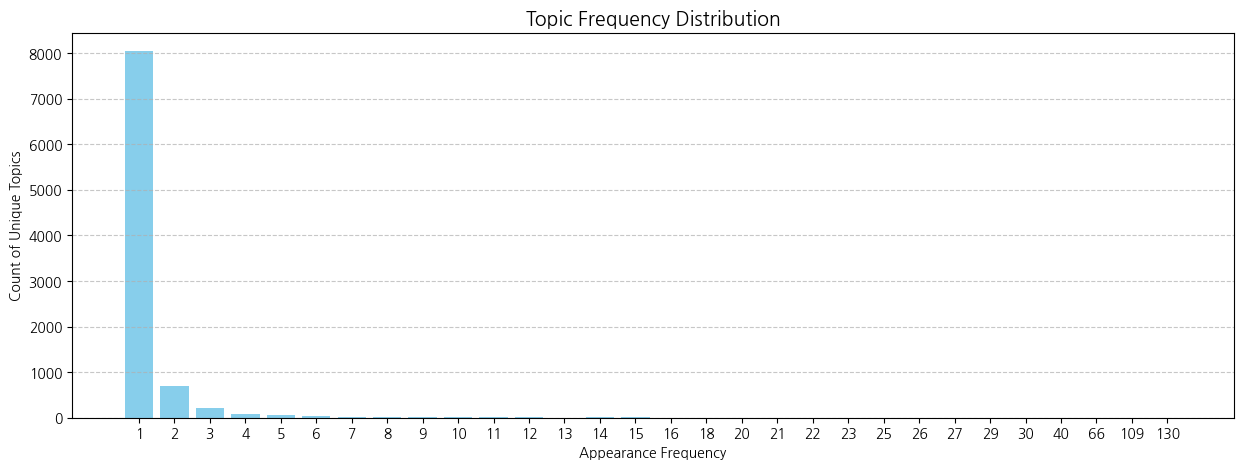

In [26]:
# topic 빈도별 분포 시각화 (Long-tail Check)
plt.figure(figsize=(15, 5))
plt.bar(count_distribution.index.astype(str), count_distribution.values, color='skyblue')
plt.title('Topic Frequency Distribution', fontsize=14)
plt.xlabel('Appearance Frequency')
plt.ylabel('Count of Unique Topics')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [27]:
# 1회성 topic 분석
df_ana = topic_counts.reset_index()
df_ana.columns = ['topic_name', 'frequency']

fq = df_ana[df_ana['frequency'] == 1]
total_count = len(train_df)
single_count = len(fq)

print(f'전체 데이터 수: {total_count}개')
print(f'1회성 토픽 비중: {(single_count / total_count) * 100:.2f}%')

전체 데이터 수: 12457개
1회성 토픽 비중: 64.55%


#### 3. 텍스트

In [28]:
# 텍스트 길이 분포
train_df['dialogue_len'] = train_df['dialogue'].apply(len)
print(train_df['dialogue_len'].describe())

count    12457.000000
mean       406.083487
std        197.566083
min         84.000000
25%        280.000000
50%        369.000000
75%        500.000000
max       2165.000000
Name: dialogue_len, dtype: float64


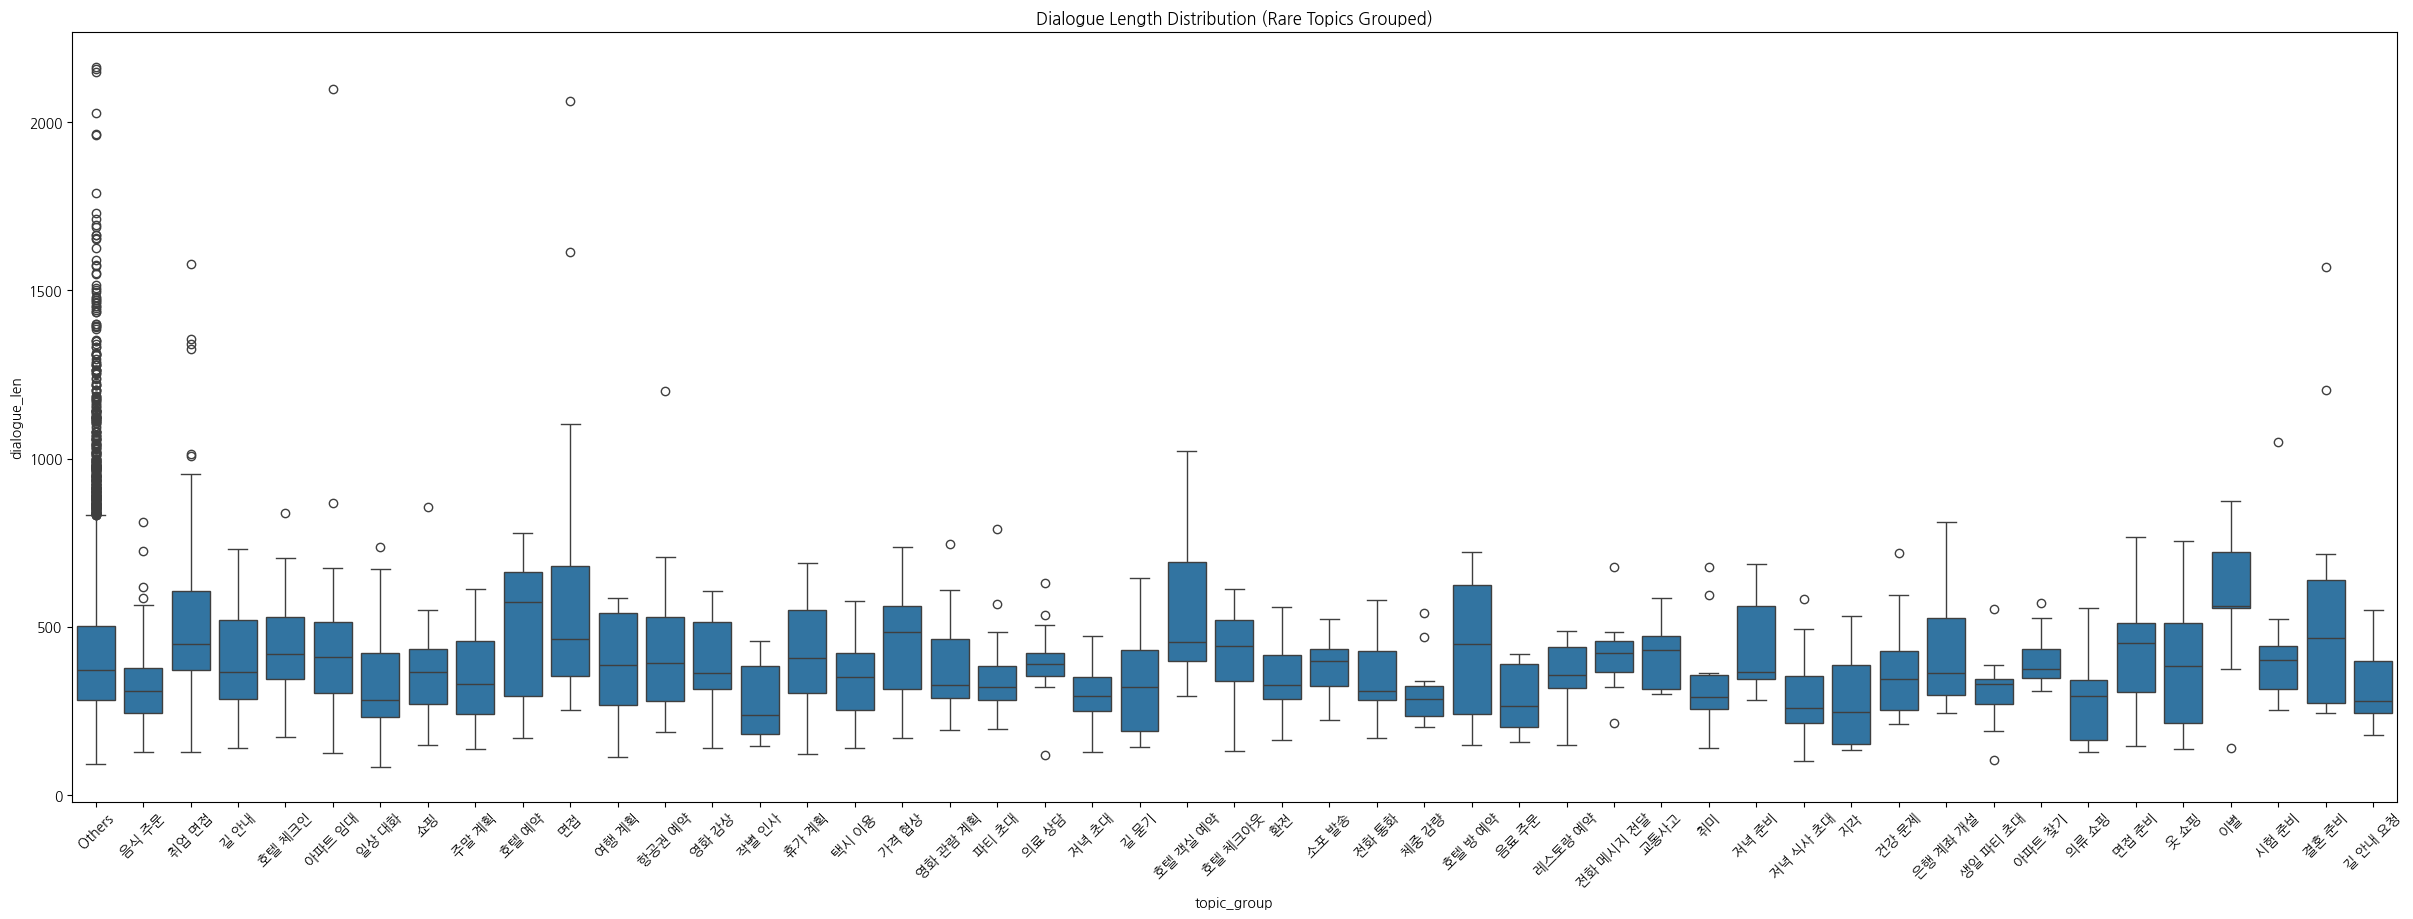

In [29]:
# 텍스트 길이 분포 topic별 시각화 (Box Plot)
rare_topics = topic_counts[topic_counts <= 10].index # 10건 이하 그룹화

train_df['topic_group'] = train_df['topic'].apply(
    lambda x: 'Others' if x in rare_topics else x
)

ordered_topics = train_df['topic_group'].value_counts().index # 빈도수 정렬

plt.figure(figsize=(30, 10))
sns.boxplot(x='topic_group', y='dialogue_len', data=train_df, order=ordered_topics)
plt.xticks(rotation=45)
plt.title('Dialogue Length Distribution (Rare Topics Grouped)')
plt.show()

In [ ]:
# 텍스트 빈도 topic별 word cloud
stop_groups = {
    'speakers': {'Person1', 'Person2', 'Person3', '사람1', '사람2'},
    'greetings': {'안녕하세요', '안녕', '반갑습니다', '감사합니다', '고맙습니다', '실례합니다', '죄송합니다', '미안해요', '알겠습니다'},
    'fillers': {'음', '아', '오', '에', '어', '글쎄', '막', '막상', '저기요'},
    'demonstratives': {'이', '그', '저', '여기', '거기', '저기', '이거', '그거', '저거', '뭐', '어떤', '다른', '왜'},
    'conjunctions': {'그리고', '하지만', '그런데', '그래서', '그럼', '그래도', '그러면'},
    'particles': {'네', '예', '아니오', '아니요', '어쩌면', '그냥', '좀', '정말', '진짜', '매우', '아주', '너무', '잘', '더', '다', '안', '아직', '가장'},
    'josa': {'가', '의', '은', '는', '을', '를', '이', '도', '로', '으로', '와', '과', '한테', '에', '에서'},
    'bound_nouns': {'수', '것', '거', '적', '분', '데', '번', '쪽', '시', '정도', '두'},
    'ending_forms': {'있어요', '있나요', '있습니다', '해요', '합니다', '할게요', '인가요', '였어요', '네요', '주세요', '거예요', '됩니다', '돼요', '싶습니다'},
    'verb_stems': {'있는', '있어', '있고', '있던', '있게', '있음', '있을', '아닌', '아니', '같아요', '같은', '대해'},
    'personal_prons': {'저는', '제가', '제', '저희', '나', '내가', '우리가', '우리'},
    'time_words': {'오늘', '내일', '어제', '지금', '이제', '요즘'},
    'etc': {'드릴까요', '생각합니다', '많은', '맞아요', '다음', '있다고', '어떻게', '좋아요', '여기서', '있네요' '좋네요', '알고', '좋은'},
}

colormaps = ['viridis', 'plasma', 'inferno', 'magma', 'cividis',
             'spring', 'summer', 'autumn', 'winter', 'cool',
             'hot', 'copper', 'Wistia', 'Set2', 'Paired']

def wordcloud_by_topic(df, topic_name):
    text = ' '.join(df[df['topic'] == topic_name]['dialogue'])

    # 화자 태그 제거
    clean_text = re.sub(r'#Person\d+#:', '', text)

    custom_stopwords = set(STOPWORDS).union(*stop_groups.values())
    # custom_stopwords = set().union(stop_groups['speakers'], stop_groups['fillers'])

    selected_cmap = random.choice(colormaps)
    wordcloud = WordCloud(
        width=1600, height=800,
        background_color='white',
        font_path='NanumGothic',
        stopwords=custom_stopwords, # 불용어 적용
        regexp=r"[\w']+",           # 단어 추출 방식 지정
        colormap=selected_cmap,
    ).generate(clean_text)

    plt.figure(figsize=(16, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud for Topic: {topic_name}')
    plt.axis('off')
    plt.show()

# top 5 topic
top_topics = train_df['topic'].value_counts().head(5).index
for t in top_topics:
    wordcloud_by_topic(train_df, t)

#### 4. 화자

최대 참여 인원: 7명
평균 참여 인원: 2.01명
줄바꿈 누락: 10건
화자 태그 포맷 위반: 67건


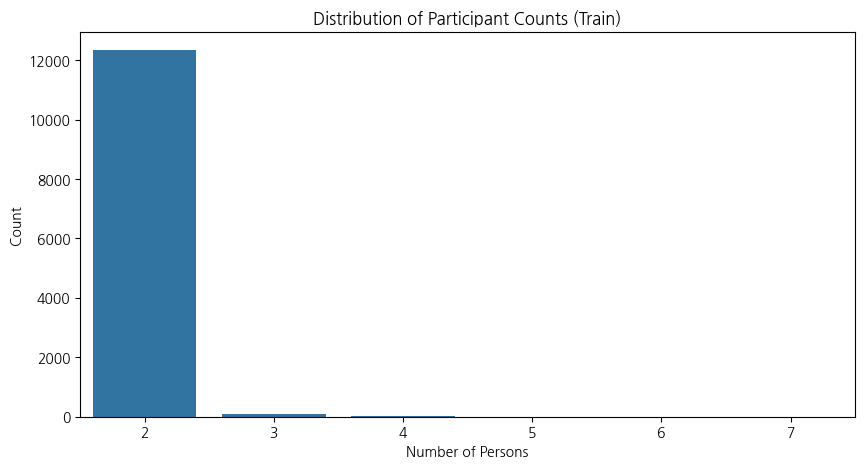

In [ ]:
def check_dialogue(df, stage='Train'):
    # 각 대화당 등장하는 인원수 추출
    def count_participants(text):
        participants = re.findall(r'#Person(\d+)#:', text)
        return len(set(participants))

    df['person_count'] = df['dialogue'].apply(count_participants)

    # 줄바꿈(\n) 규칙 준수 여부 확인
    df['has_newline'] = df['dialogue'].str.contains('\n')
    newline_violation = df[df['has_newline'] == False]

    # 화자 태그 포맷 위반 확인
    def check_format_violation(text):
        # 콜론이 빠진 패턴 (#Person1# ) 등 검사
        bad_patterns = re.findall(r'#Person\d+#(?!\:)', text)
        return len(bad_patterns) > 0

    df['format_error'] = df['dialogue'].apply(check_format_violation)

    print(f"최대 참여 인원: {df['person_count'].max()}명")
    print(f"평균 참여 인원: {df['person_count'].mean():.2f}명")
    print(f'줄바꿈 누락: {len(newline_violation)}건')
    print(f"화자 태그 포맷 위반: {df['format_error'].sum()}건")

    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x='person_count')
    plt.title(f'Distribution of Participant Counts ({stage})')
    plt.xlabel('Number of Persons')
    plt.ylabel('Count')
    plt.show()

check_dialogue(train_df, 'Train')